# Assignment 2: Data Wrangling and Exploratory Analysis

Dataset: UCI Heart Disease Data (multi-site: Cleveland, Hungary, Switzerland, VA Long Beach)

## Task 1: Dataset Selection and Schema Report

### Import the numpy, pandas and matplotlib

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load the dataset and print its shape, column names, and dtypes


In [19]:
df = pd.read_csv('../data/raw/heart_disease_uci.csv')
print("Shape:", df.shape)
print("Column names:", df.columns.tolist())
print("Data types:")
print(df.dtypes)

Shape: (920, 16)
Column names: ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
Data types:
id            int64
age           int64
sex             str
dataset         str
cp              str
trestbps    float64
chol        float64
fbs          object
restecg         str
thalch      float64
exang        object
oldpeak     float64
slope           str
ca          float64
thal            str
num           int64
dtype: object


### Null counts per column

In [20]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


### Unique-value counts per column


In [ ]:
print("Unique values per column:")
print(df.nunique())

Unique values per column:
id          920
age          50
sex           2
dataset       4
cp            4
trestbps     61
chol        217
fbs           2
restecg       3
thalch      119
exang         2
oldpeak      53
slope         3
ca            4
thal          3
num           5
dtype: int64


### Dataset source, license, and why chosen

**Dataset:** UCI Heart Disease Data
**Source:** https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data:  is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia.
**License:** "Data files © Original Authors".
**Why chosen:** 920 rows with a mix of numeric (age, cholesterol, blood pressure, max heart rate) and categorical (sex, chest pain type, thal, site) columns, real-world messiness (missingness that varies sharply by collection site  a good test case for deliberate cleaning decisions), and a natural multi-group structure (4 sites) that makes groupby/merge feature engineering meaningful rather than decorative.

## Task 2: Data Cleaning

Using what we observed in Task 1:
1. Handle missing values — impute, drop, or flag, justified per column
2. Fix dtype issues
3. Remove or document duplicate rows

In [5]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


No duplicate found, so there is nothing to drop or document there.

In [21]:
#Handling Missing values with imputation:
numeric_cols_to_impute = ['trestbps', 'chol', 'thalch', 'oldpeak']
for col in numeric_cols_to_impute:
    df[col] = df[col].fillna(df[col].median())

In [22]:
# Handling categorical missing values with mode imputation
categorical_cols_to_impute = ['fbs', 'exang', 'restecg']
for col in categorical_cols_to_impute:
    df[col] = df[col].fillna(df[col].mode()[0])

In [24]:
# Handling categorical missing values with a placeholder
df['slope'] = df['slope'].fillna('Unknown')

In [25]:
# Dropping columns with a large share of missing values
print("Shape before dropping ca/thal:", df.shape)
df = df.drop(columns=['ca', 'thal'])
print("Shape after dropping ca/thal:", df.shape)

Shape before dropping ca/thal: (920, 16)
Shape after dropping ca/thal: (920, 14)


In [26]:
# Confirm no missing values remain
print(df.isnull().sum())

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
num         0
dtype: int64


In [27]:
# Convert fbs and exang to boolean
print("Before:", df['fbs'].dtype, df['exang'].dtype)
df['fbs'] = df['fbs'].astype('boolean')
df['exang'] = df['exang'].astype('boolean')
print("After:", df['fbs'].dtype, df['exang'].dtype)

Before: object object
After: boolean boolean


## Task 3: Feature Engineering with GroupBy and Merge

In [28]:
# Create a new column 'has_disease' based on the 'num' column
df['has_disease'] = df['num'] > 0

In [29]:
# Group by 'dataset' and calculate mean age and diagnosis rate
print("Shape before groupby-merge:", df.shape)

site_stats = df.groupby('dataset').agg(
    site_mean_age=('age', 'mean'),
    site_diagnosis_rate=('has_disease', 'mean')
).reset_index()

df = df.merge(site_stats, on='dataset', how='left')

print("Shape after groupby-merge:", df.shape)
df[['dataset', 'age', 'site_mean_age', 'has_disease', 'site_diagnosis_rate']].head()

Shape before groupby-merge: (920, 15)
Shape after groupby-merge: (920, 17)


,dataset,age,site_mean_age,has_disease,site_diagnosis_rate
0,Cleveland,63,54.351974,False,0.457237
1,Cleveland,67,54.351974,True,0.457237
2,Cleveland,67,54.351974,True,0.457237
3,Cleveland,37,54.351974,False,0.457237
4,Cleveland,41,54.351974,False,0.457237


In [30]:
# Create a pivot table to count the number of patients by dataset and cp (chest pain type)
print("Main dataframe shape (unchanged by this step):", df.shape)

cp_by_site = df.pivot_table(
    index='dataset',
    columns='cp',
    values='id',
    aggfunc='count',
    fill_value=0
)
print("Pivot table shape:", cp_by_site.shape)
cp_by_site

Main dataframe shape (unchanged by this step): (920, 17)
Pivot table shape: (4, 4)


cp,asymptomatic,atypical angina,non-anginal,typical angina
dataset,,,,
Cleveland,144,51,86,23
Hungary,123,105,54,11
Switzerland,98,4,17,4
VA Long Beach,131,14,47,8


## Task 4: NumPy-Based Computation

In [31]:
# Calculate z-scores for the 'chol' column
chol_array = df['chol'].to_numpy()
chol_zscore = (chol_array - chol_array.mean()) / chol_array.std()

print("Mean:", chol_zscore.mean())
print("Std:", chol_zscore.std())
print("Min:", chol_zscore.min())
print("Max:", chol_zscore.max())

df['chol_zscore'] = chol_zscore
df[['chol', 'chol_zscore']].head()

Mean: -9.267948727305654e-17
Std: 1.0
Min: -1.8343462719457118
Max: 3.6987337092663792


,chol,chol_zscore
0,233.0,0.303643
1,286.0,0.789967
2,229.0,0.266939
3,250.0,0.459634
4,204.0,0.037541


## Task 5: Exploratory Visualization

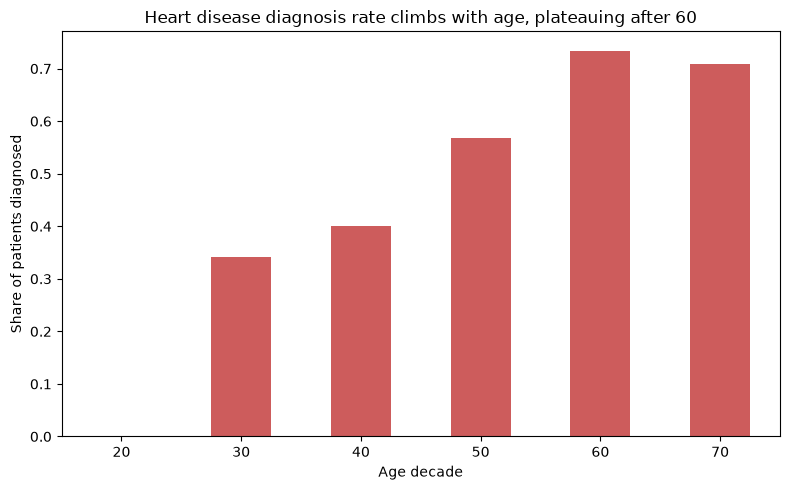

In [32]:
# Create a new column 'age_decade' to group ages into decades
df['age_decade'] = (df['age'] // 10) * 10
rate_by_decade = df.groupby('age_decade')['has_disease'].mean()

plt.figure(figsize=(8, 5))
rate_by_decade.plot(kind='bar', color='indianred')
plt.title("Heart disease diagnosis rate climbs with age, plateauing after 60")
plt.xlabel("Age decade")
plt.ylabel("Share of patients diagnosed")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/a2_chart1.png", dpi=150, bbox_inches="tight")
plt.show()

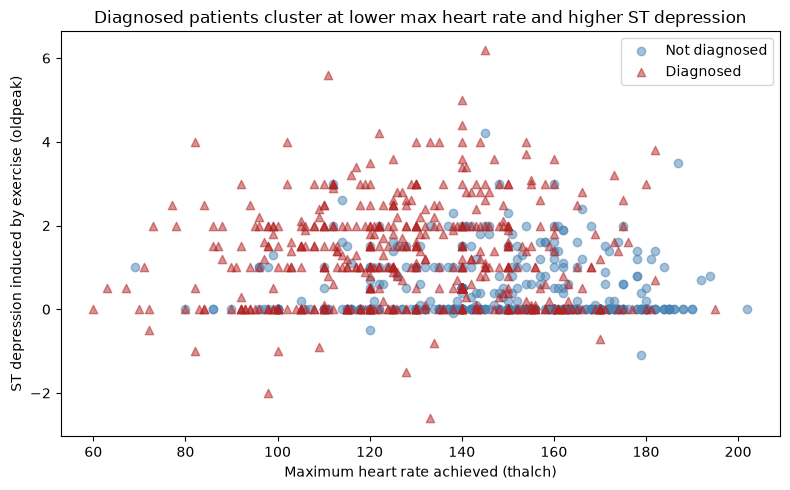

In [33]:
# Scatter plot of thalch vs oldpeak, colored by diagnosis status
plt.figure(figsize=(8, 5))
for label, marker, color in [(False, 'o', 'steelblue'), (True, '^', 'firebrick')]:
    subset = df[df['has_disease'] == label]
    plt.scatter(
        subset['thalch'], subset['oldpeak'],
        alpha=0.5, marker=marker, color=color,
        label='Diagnosed' if label else 'Not diagnosed'
    )

plt.title("Diagnosed patients cluster at lower max heart rate and higher ST depression")
plt.xlabel("Maximum heart rate achieved (thalch)")
plt.ylabel("ST depression induced by exercise (oldpeak)")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/a2_chart2.png", dpi=150, bbox_inches="tight")
plt.show()

## Task 6: Cleaned Dataset and Report

In [34]:
# Save the cleaned, feature-engineered dataset
df.to_csv("../data/processed/heart_disease_clean.csv", index=False)
print("Saved cleaned dataset:", df.shape)

Saved cleaned dataset: (920, 19)


See `reports/weekend-a2-report.md` for the full write-up (question explored, findings, and a limitation) referencing both charts, and `reports/weekend-a2-reflection.md` for the Task 7 reflection.